In [21]:
import cv2
import matplotlib.pyplot as plt
import maxrf4u as mx
import falnama
import numpy as np
import os
import re

In [22]:
datastack_files = falnama.Falnama_maxrf_data().get_datastack_files()

In [23]:
datastack_files

['/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-01_400_600_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-03_250_300_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-08_250_300_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-10_250_300_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-12_250_300_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-13_400_600_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-17_400_600_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-18_400_300_50_det.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-18_400_500_50.datastack',
 '/home/koen-van-tilburg/snap/jupyterlab-d

In [24]:
ds = mx.DataStack(datastack_files[-1])

In [25]:
ds.tree()

/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (31, 4096) float64
├── hotmax_noiselines (31, 4096) float64
├── hotmax_peak_idxs_flat (34,) int64
├── hotmax_peak_idxs_list (31, 2) int64
├── hotmax_spectra (31, 4096) float32
├── hotmax_spots (31, 2) int64
├── hotmax_subpeak_idxs_list (31, 18) int64
├── imvis_extent (4,) int64
├── imvis_reg (617, 357, 3) uint8
├── imvis_reg_highres (8256, 4777, 3) uint8
├── maxrf_cube (617, 357, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 617, 357) float32
├── nmf_gausscomponents (35, 4096) float32
├── nmf_peakmaps (35, 617, 357) float32
└── nmf_peaks2elements_matrix (18, 34) float32

/home/koen-van-tilburg/snap/jupyterlab-desktop/common/.cache/falnama/WM-71803-35_400_500_50.datastack:




In [26]:
image = ds.read('imvis_reg')

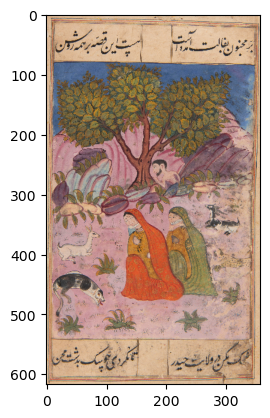

In [27]:
plt.imshow(image)

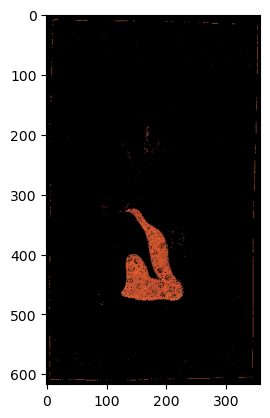

In [35]:
# Convert BGR to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# define range of blue color in HSV
lower = np.array([110, 150, 0])
upper = np.array([140, 255, 255])

# Create a mask. Threshold the HSV image to get only yellow colors
mask = cv2.inRange(hsv, lower, upper)

# Bitwise-AND mask and original image
result = cv2.bitwise_and(image,image, mask= mask)

# display the mask and masked image
#plt.imshow(mask)
plt.imshow(result)